C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


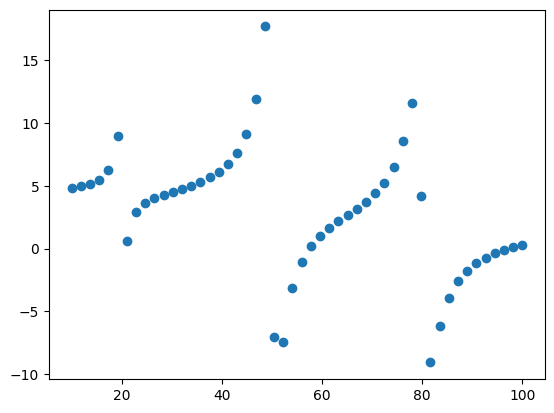

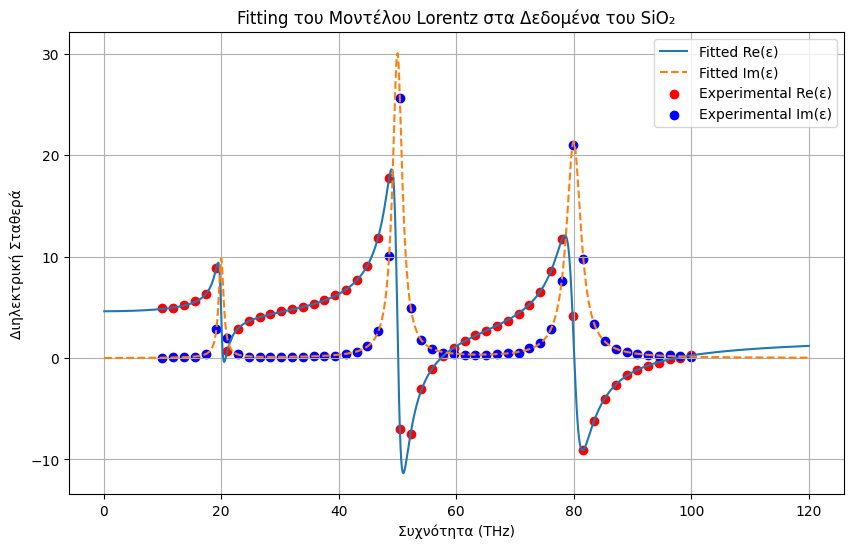

In [16]:
import numpy as np
import matplotlib.pyplot as plt


# Ορισμός του μοντέλου Lorentz για την διηλεκτρική σταθερά
def lorentz_dielectric(freq, eps_inf, resonances):
    """
    Επιστρέφει την διηλεκτρική συνάρτηση για μια συχνότητα (ή έναν πίνακα συχνοτήτων).
    
    freq: Συχνότητα(ες) σε THz.
    eps_inf: Διηλεκτρική σταθερά στο υψηλής συχνότητας όριο.
    resonances: Λίστα από πλειάδες (omega0, gamma, delta_eps) για κάθε συντονισμό.
    """
    # Αρχικοποίηση της διηλεκτρικής σταθεράς ως ένας σύνθετος αριθμός
    eps = eps_inf + 0 * freq * 1j
    for omega0, gamma, delta_eps in resonances:
        eps += delta_eps * omega0**2 / (omega0**2 - freq**2 - 1j * gamma * freq)
    return eps

# Δημιουργία "πειραματικών" δεδομένων
np.random.seed(0)  # για αναπαραγωγιμότητα

# Ορισμός των "αληθινών" παραμέτρων για το SiO₂
true_eps_inf = 2.1
true_resonances = [(20, 1, 0.5), 
                   (50, 2, 1.2), 
                   (80, 3, 0.8)]

# Δημιουργία ενός πλέγματος συχνοτήτων (π.χ., 50 σημεία μεταξύ 10 και 100 THz)
freq_exp = np.linspace(10, 100, 50)
epsilon_true = lorentz_dielectric(freq_exp, true_eps_inf, true_resonances)
plt.scatter(freq_exp,epsilon_true)

# Σχεδίαση του μοντέλου με τις προσαρμοσμένες παραμέτρους σε ένα πυκνό πλέγμα συχνοτήτων
freq_fit = np.linspace(0.1, 120, 1000)
# Δημιουργία λίστας με τους προσαρμοσμένους συντονισμούς
fitted_resonances = [(fitted_params[1+3*i], fitted_params[1+3*i+1], fitted_params[1+3*i+2]) for i in range(3)]
eps_fit = lorentz_dielectric(freq_fit, fitted_params[0], fitted_resonances)

# Σχεδίαση αποτελεσμάτων
plt.figure(figsize=(10, 6))
plt.plot(freq_fit, eps_fit.real, label="Fitted Re(ε)")
plt.plot(freq_fit, eps_fit.imag, label="Fitted Im(ε)", linestyle="dashed")
plt.scatter(freq_exp, epsilon_exp.real, color="red", label="Experimental Re(ε)")
plt.scatter(freq_exp, epsilon_exp.imag, color="blue", label="Experimental Im(ε)")
plt.xlabel("Συχνότητα (THz)")
plt.ylabel("Διηλεκτρική Σταθερά")
plt.title("Fitting του Μοντέλου Lorentz στα Δεδομένα του SiO₂")
plt.legend()
plt.grid()
plt.show()

